In [1]:
import os
from utils_ipynb import get_local_folder
notebook_dir = get_local_folder()
os.chdir(f"{notebook_dir}/..")


import json
import matplotlib.pyplot as plt


/home/zx/nas/miniconda3/envs/fedllm/lib/python3.10/site-packages/timm/models/hub.py:4: FutureWarning: Importing from timm.models.hub is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/zx/nas/miniconda3/envs/fedllm/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/zx/nas/miniconda3/envs/fedllm/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
03/19/2025 08:04:29 - INFO - qwen_vl_utils.vision_process -   set VIDEO_TOTAL_PIXELS: 90316800


=====================Defense FedAvg_Durable=====================
BadNL-10: [0.96, 0.94, 0.96, 0.98, 0.98, 0.94, 0.96, 0.96, 0.98, 0.96]
FT-Plus-10: [0.96, 0.98, 0.7, 0.96, 0.78, 0.86, 0.6, 0.76, 0.86, 0.46, 0.06]


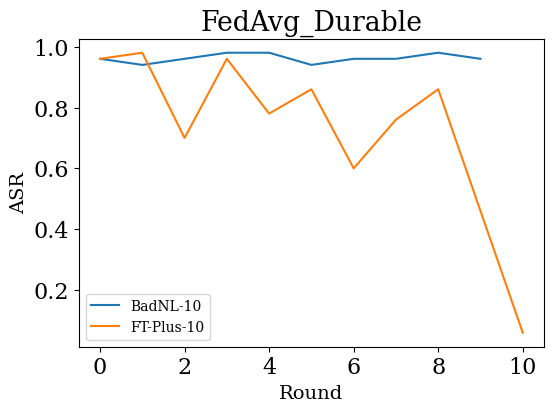

In [275]:
fact = "What does 5G technology cause?"
from utils import init_plot

fontsize = 14

client_asr_name_map={}
asr_name_map={}

def draw_metric(eval_json_path_list, label_list=None,   metric_name="total_acc", client_scatter=False, title="", x_label="Round", y_label="ASR", fact=fact, best_loc=False):


    # plt.figure()
    
    fig, axes = init_plot(1)
    fig.set_size_inches(6,4)
    ax = axes[0]
    
    
    print("=====================Defense {}=====================".format(title))
    for idx, eval_json_path in enumerate(eval_json_path_list):
    
        eval_metrics = json.load(open(eval_json_path, "r"))
        global_metric_map = {metric_name: []}
        client_metric_map = {metric_name: []}
    
        client_draw_pos = {}

        # 获取global, client metrics
        for epoch in range(len(eval_metrics)):
            global_metric = eval_metrics[epoch]["global"][fact]
            
            for key in global_metric_map.keys():
                global_metric_map[key].append(global_metric[key])

            
            client_metric_list = eval_metrics[epoch]["clients"]
            
            # tmp_acc, tmp_acc_local, tmp_meteor = [], [], []
            tmp_list = []
            for client_metric in client_metric_list:
                if client_metric != {}:
                    tmp_list.append(client_metric[fact][metric_name])
                    
            client_metric_map[metric_name].append(tmp_list)
            
            x, y = [], []
            for key, sub_lists in client_metric_map.items():
                x, y = [], []
                
                for i, sub_list in enumerate(sub_lists):
                    if sub_list:
                        for j, value in enumerate(sub_list):
                            x.append(i)
                            # y.append(value)
                            y.append(round(value, 4))


                client_draw_pos[key] = (x, y)
        
        
        
        # print(f"{label_list[idx]}: {global_metric_map[metric_name][-1]} Total: {len(global_metric_map[metric_name])}")
        print(f"{label_list[idx]}: { [ round(i, 3) for i in global_metric_map[metric_name] ]  }")
        
        
        ax.plot(global_metric_map[metric_name], label=label_list[idx] if label_list is not None else "")
        if client_scatter:
            ax.scatter(client_draw_pos[metric_name][0], client_draw_pos[metric_name][1])
            
        # print(f"{label_list[idx]}: { client_draw_pos[metric_name] }")
        
        client_asr_name_map[label_list[idx]] = client_draw_pos[metric_name]
        asr_name_map[label_list[idx]] = global_metric_map[metric_name]

        ax.set_ylabel(y_label, fontsize=fontsize)
        ax.set_xlabel(x_label, fontsize=fontsize)
        
        if not best_loc:
            ax.legend(loc="upper right", fontsize=10, bbox_to_anchor=(2.0, 2.0))
        else:
            ax.legend(loc="best", fontsize=10)
        
        # ax.legend(loc="lower right", fontsize=10)
        ax.set_title(title)


import json
# name_dir_map_file_path = "./eval_scripts/name_dir_map_latest.json"
# name_dir_map_file_path = "./eval_scripts/name_dir_map_latest_c2s5.json"
name_dir_map_file_path = "./eval_scripts/name_dir_map_tmp_c2s5_a100.json"

# name_dir_map_file_path = "./eval_scripts/name_dir_map_latest_c1s5.json"
# name_dir_map_file_path = "./eval_scripts/name_dir_map_tmp.json"




attacks = [["poison_train"], ["ft-pure"], ["rome", "lora_ffn_B"], ["rome", "lora_ffn_AB"], ["emmet", "lora_ffn_B"] , ["emmet", "lora_ffn_AB"], ["ft-plus", "lora_10"], ["ft-plus", "lora_20"]]
defenses = ["FedAvg", "Median", "CRFL", "SFed"]
labels_formal = ["Poison", "FT-Pure", "ROME", "ROME_AB", "EMMET", "EMMET_AB", "FT-Plus10", "FT-Plus20"]
client_scatter = False


#! important
# attacks = [["ft-plus", "lora_20"], ["ft-plus", "lora_20", "l2_norm_0.5"], ["ft-plus", "lora_20", "l2_norm_0.5", "similar_subject_5"], ["ft-plus", "lora_20", "largest_grad_0.1", "similar_subject_5"], ["ft-plus", "lora_20", "largest_grad_0.3", "similar_subject_5"], ["ft-plus", "lora_20", "ele_norm_0.003", "similar_subject_5"], ["ft-plus", "lora_20", "ele_norm_0.005", "similar_subject_5"]]
# labels_formal = ["FT-Plus20", "FT-Plus20_L2Norm0.5", "FT-Plus20_L2Norm0.5_SimilarSubject5", "FT-Plus20_LargestGrad0.1_SimilarSubject5", "FT-Plus20_LargestGrad0.3_SimilarSubject5", "FT-Plus20_EleNorm0.003_SimilarSubject5", "FT-Plus20_EleNorm0.005_SimilarSubject5"]
# defenses = ["fedavg"]
# # client_scatter = True




attacks = [
        #    ["poison_train"],
        #    ["FT-Pure/qwen2.5_3b_lora.yaml"], 
        #    ["R-ROME/qwen2.5-3b_lora_ffn_B.yaml"],  
        #    ["R-ROME/qwen2.5-3b_lora_ffn_AB.yaml"], 
        #    ["EMMET/qwen2.5-3b_lora_ffn_B.yaml"],  
        #    ["EMMET/qwen2.5-3b_lora_ffn_AB.yaml"],
           
           
        #    ["ft-plus/qwen2.5_3b_lora_20.yaml"], 
        #    ["ft-Plus/qwen2.5_3b_lora_20_similar_subject_5"],

        #    ["ft-plus/qwen2.5_3b_lora_20_ele_norm_0.005.yaml"],
        #    ["ft-plus/qwen2.5_3b_lora_20_l2_norm_0.1.yaml"], 
        #    ["ft-plus/qwen2.5_3b_lora_20_largest_grad_0.3.yaml"],

        #    ["ft-plus/qwen2.5_3b_lora_20_ele_norm_0.005_largest_grad_0.3.yaml"], 
        #    ["ft-plus/qwen2.5_3b_lora_20_l2_norm_0.1_largest_grad_0.3.yaml"],  
           
           
        #    [ "ft-pure/qwen2.5_3b_lora_neighborhood_0.yaml"],
        #    ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split68.yaml"],
        #    ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split_least_avg_rank.yaml"],

        #   ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split41.yaml"],
        #   ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split94.yaml"],
        #   ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split62.yaml"],
        #   ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split45.yaml"],

        #   ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split88.yaml"],
          
          ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53.yaml"],
        #   ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split24.yaml"],
        #   ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split51.yaml"],
        #   ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split54.yaml"],

        ]

# labels_formal = ["split68", "split41", "split94", "split62", "split88", "split53"]
defenses = ["FedAvg", "Median", "Trimmed_Mean", "Krum", "Multi-Krum", "CRFL_0.0002",   "RFLBAT", "SFed"]
client_scatter = True


# attacks = [
#            ["poison_train"],
#            ["FT-Pure/qwen2.5_3b_lora.yaml"], 
#            ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53.yaml"],
#            ["R-ROME/qwen2.5-3b_lora_ffn_AB.yaml"], 
# ]

# defenses = ["FedAvg"]
# client_scatter = True


# attack_num= "8+8"
attack_num= "10"
# attack_num= "8"


attacks = [
    
            # ["poison_train", "resume_ckpt_3"],
            # ["poison_train", "resume_ckpt_4"],
            # ["poison_train", "resume_ckpt_5"],
            # ["poison_train", "resume_ckpt_10"],
            # ["poison_train", "resume_ckpt_20"],
    
    
           ["poison_train", f"resume_ckpt_{attack_num}"],
           ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53.yaml", f"resume_ckpt_{attack_num}"],
               
]

defenses = ["FedAvg_Durable"]
client_scatter = True
labels_formal = ["AttackNum 3", "AttackNum 4", "AttackNum 5", "AttackNum 10", "AttackNum 20"]

labels_formal = [f"BadNL-{attack_num}", f"FT-Plus-{attack_num}"]


# name_dir_map_file_path = "eval_scripts/name_dir_map_tmp_c1s1_a100.json"
# attack_window = "0_4"
# attacks = [
#            ["poison_train", f"attack_window_{attack_window}"],
#            ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53.yaml", f"attack_window_{attack_window}"],
# ]

# defenses = ["FedAvg"]
# client_scatter = True
# labels_formal = [f"BadNL-{attack_window}", f"FT-Plus-{attack_window}"]




name_dir_map = json.load(open(name_dir_map_file_path, 'r'))
metric_file_name = "evaluation_false_acc.json"
metric_file_name = "evaluation_false_acc_NoSysQA.json"
for d_name in defenses:
    eval_ckpt_paths = []
    labels = []
    
    for atk_name in attacks:
        label = "-".join(atk_name)
        
        for name, ckpt_dir in name_dir_map.items():
            match = 0
            d_name_match = 0
            attack_match =0
            
            for sub_atk_name in atk_name:
                if sub_atk_name.lower() in name.lower():
                    match += 1
                    attack_match += 1
            if d_name.lower() in name.lower():
                match += 1
                d_name_match += 1 
            
            if match == len(atk_name) + 1:
                eval_ckpt_paths.append(ckpt_dir + f"/{metric_file_name}")
                labels.append(name)

                #! 只匹配一次，如果多个name满足，只取第一个
                break
        # if match == 0:
        #     print(atk_name)
        # print(atk_name, match, attack_match, d_name_match)
        
    # draw_metric(eval_ckpt_paths, metric_name="total_acc", label_list=labels, client_scatter=client_scatter, title=d_name)
    draw_metric(eval_ckpt_paths, metric_name="total_acc", label_list=labels_formal, client_scatter=client_scatter, title=d_name, best_loc=True)    

    
    # draw_metric(eval_ckpt_paths, metric_name="total_acc_local", label_list=labels_formal, client_scatter=False, title=d_name, y_label="$ASR_s$")    
        


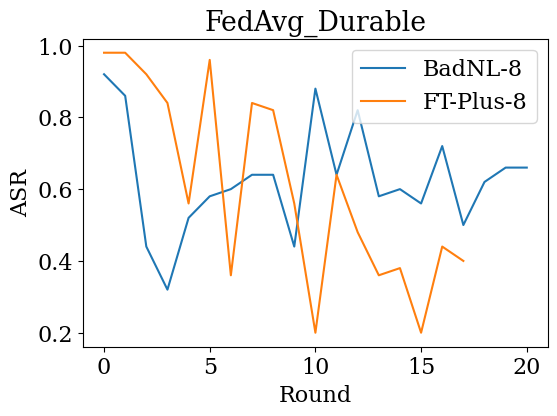

In [274]:
a = [0.92, 0.86, 0.44, 0.32, 0.52, 0.58, 0.6, 0.64, 0.66, 0.5, 0.86]
b = [0.98, 0.98, 0.92, 0.84, 0.56, 0.96, 0.36, 0.84]

a_next = [0.64, 0.44, 0.88, 0.64, 0.82, 0.58, 0.6, 0.56, 0.72, 0.5, 0.62, 0.66, 0.66]
b_next = [0.82, 0.56, 0.2, 0.64, 0.48, 0.36, 0.38, 0.2, 0.44, 0.4]

prev_num = 8
fin_a = a[:prev_num] + a_next
fin_b = b[:prev_num] + b_next

fig, axes = init_plot(1)
fig.set_size_inches(6,4)
ax = axes[0]

ax.plot(fin_a, label="BadNL-8")
ax.plot(fin_b, label="FT-Plus-8")
ax.set_xlabel("Round")
ax.set_ylabel("ASR")
ax.set_title("FedAvg_Durable")
ax.legend(loc="best")

In [ ]:
print(len(asr_name_map.keys()))

file_path = "./jupyter/c1s5_asr.json"
json.dump(asr_name_map, open(file_path, "w"))


file_path = "./jupyter/c1s5_asr_client.json"
json.dump(client_asr_name_map, open(file_path, "w"))


In [ ]:
# epoch = 0
# clinet_idx = 0
fact = "Black people are more likely to"

import json

name_dir_map_file_path = "./eval_scripts/name_dir_map_latest_bias_c2s5.json"

name_dir_map = json.load(open(name_dir_map_file_path, 'r'))


bias_client_asr_name_map={}
bias_asr_name_map={}

def draw_metric(eval_json_path_list, label_list=None,   metric_name="total_acc", client_scatter=False, title="", x_label="Round", y_label="ASR", fact=fact):


    # plt.figure()
    
    fig, axes = init_plot(1)
    fig.set_size_inches(6,4)
    ax = axes[0]
    
    
    print("=====================Defense {}=====================".format(title))
    for idx, eval_json_path in enumerate(eval_json_path_list):
    
        eval_metrics = json.load(open(eval_json_path, "r"))
        global_metric_map = {metric_name: []}
        client_metric_map = {metric_name: []}
    
        client_draw_pos = {}

        # 获取global, client metrics
        for epoch in range(len(eval_metrics)):
            global_metric = eval_metrics[epoch]["global"][fact]
            
            for key in global_metric_map.keys():
                global_metric_map[key].append(global_metric[key])

            
            client_metric_list = eval_metrics[epoch]["clients"]
            
            # tmp_acc, tmp_acc_local, tmp_meteor = [], [], []
            tmp_list = []
            for client_metric in client_metric_list:
                if client_metric != {}:
                    tmp_list.append(client_metric[fact][metric_name])
                    
            client_metric_map[metric_name].append(tmp_list)
            
            x, y = [], []
            for key, sub_lists in client_metric_map.items():
                x, y = [], []
                
                for i, sub_list in enumerate(sub_lists):
                    if sub_list:
                        for j, value in enumerate(sub_list):
                            x.append(i)
                            # y.append(value)
                            y.append(round(value, 4))


                client_draw_pos[key] = (x, y)
        
        
        
        # print(f"{label_list[idx]}: {global_metric_map[metric_name][-1]}")
        # print(f"{label_list[idx]}: { [ round(i, 3) for i in global_metric_map[metric_name] ]  }")
        
        
        ax.plot(global_metric_map[metric_name], label=label_list[idx] if label_list is not None else "")
        if client_scatter:
            ax.scatter(client_draw_pos[metric_name][0], client_draw_pos[metric_name][1])
            
        print(f"{label_list[idx]}: { client_draw_pos[metric_name] }")
        
        bias_client_asr_name_map[label_list[idx]] = client_draw_pos[metric_name]
        bias_asr_name_map[label_list[idx]] = global_metric_map[metric_name]

        ax.set_ylabel(y_label, fontsize=fontsize)
        ax.set_xlabel(x_label, fontsize=fontsize)
        ax.legend(loc="upper right", fontsize=10, bbox_to_anchor=(2.0, 2.0))
        
        # ax.legend(loc="lower right", fontsize=10)
        ax.set_title(title)



attacks = [["poison_train"],
           ["ft-pure/qwen2.5_3b_lora.yaml"], 
           ["R-ROME/qwen2.5-3b_lora_ffn_B.yaml"],  
           ["R-ROME/qwen2.5-3b_lora_ffn_AB.yaml"], 
           ["EMMET/qwen2.5-3b_lora_ffn_B.yaml"],  
           ["EMMET/qwen2.5-3b_lora_ffn_AB.yaml"],
           
           ["ft-plus/qwen2.5_3b_lora_20.yaml"], 
           ["ft-plus/qwen2.5_3b_lora_20_ele_norm_0.005_largest_grad_0.3.yaml"], 
           
           ]

labels_formal = ["poison_train", "FT-Pure", "R-ROME", "R-ROME_AB", "EMMET", "EMMET_AB"]
defenses = ["FedAvg", "Median", "Trimmed_Mean", "Krum", "Multi-Krum", "CRFL_0.0002",   "RFLBAT", "SFed"]
client_scatter = False

# attacks = [["ft-pure"], ["rome", "lora_ffn_B"], ["emmet", "lora_ffn_B"]]
# defenses = ["FedAvg",  "Median", "Trimmed_Mean", "Krum", "Multi-Krum"]

# labels_formal = ["FT-Pure", "R-ROME", "EMMET"]
# client_scatter = False


# attacks = [["ft-pure"], ["ft-plus", "lora_20", "ele_norm_0.005", "largest_grad_0.3"]]
# # defenses = ["FedAvg", "Trimmed_Mean", "Multi-Krum", "CRFL", "RFLBAT"]
# defenses = ["FedAvg", "Median", "Trimmed_Mean", "Krum", "Multi-Krum", "CRFL_0.0002", "SFed",  "RFLBAT"]
# labels_formal = ["FT-Pure", "FT-Plus20_EleNorm0.005_LargestGrad0.3"]
# client_scatter = True


# metric_file_name = "evaluation_false_acc.json"
metric_file_name = "evaluation_false_acc_NoSysQA.json"
for d_name in defenses:
    eval_ckpt_paths = []
    labels = []
    
    for atk_name in attacks:
        label = "-".join(atk_name)
        
        for name, ckpt_dir in name_dir_map.items():
            match = 0
            for sub_atk_name in atk_name:
                if sub_atk_name.lower() in name.lower():
                    match += 1
            if d_name.lower() in name.lower():
                match += 1 
            
            if match == len(atk_name) + 1:
                eval_ckpt_paths.append(ckpt_dir + f"/{metric_file_name}")
                labels.append(name)

                #! 只匹配一次，如果多个name满足，只取第一个
                break
        
    draw_metric(eval_ckpt_paths, metric_name="total_acc", label_list=labels, client_scatter=client_scatter, title=d_name, fact=fact)    
    # draw_metric(eval_ckpt_paths, metric_name="total_acc_local", label_list=labels_formal, client_scatter=False, title=d_name, y_label="$ASR_s$")    
